In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from vgg import VGG

import datasets
from collections import defaultdict
import re

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

import numpy as np
import pandas as pd

import torchvision.transforms as transforms
import torchvision

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from typing import Dict, List, Any
from tqdm.auto import tqdm

# Set style for better visualizations
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

In [2]:
'''ConvNet-AIG in PyTorch.

Residual Network is from the original ResNet paper:
[1] Kaiming He, Xiangyu Zhang, Shaoqing Ren, Jian Sun
    Deep Residual Learning for Image Recognition. arXiv:1512.03385

Adaptive Inference Graphs is from the original ConvNet-AIG paper:
[2] Andreas Veit, Serge Belognie
    Convolutional Networks with Adaptive Inference Graphs. ECCV 2018

'''


import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np
from torch.autograd import Variable

import torch
import torch.nn.functional as F
from torch.autograd import Variable

"""
Gumbel Softmax Sampler
Requires 2D input [batchsize, number of categories]

Does not support sinlge binary category. Use two dimensions with softmax instead.
"""

class GumbleSoftmax(torch.nn.Module):
    def __init__(self, hard=False):
        super(GumbleSoftmax, self).__init__()
        self.hard = hard
        self.gpu = False
        
    def cuda(self):
        self.gpu = True
    
    def cpu(self):
        self.gpu = False
        
    def sample_gumbel(self, shape, eps=1e-10):
        """Sample from Gumbel(0, 1)"""
        noise = torch.rand(shape)
        noise.add_(eps).log_().neg_()
        noise.add_(eps).log_().neg_()
        if self.gpu:
            return Variable(noise).cuda()
        else:
            return Variable(noise)

    def sample_gumbel_like(self, template_tensor, eps=1e-10):
        uniform_samples_tensor = template_tensor.clone().uniform_()
        gumble_samples_tensor = - torch.log(eps - torch.log(uniform_samples_tensor + eps))
        return gumble_samples_tensor

    def gumbel_softmax_sample(self, logits, temperature):
        """ Draw a sample from the Gumbel-Softmax distribution"""
        dim = logits.size(-1)
        gumble_samples_tensor = self.sample_gumbel_like(logits.data)
        gumble_trick_log_prob_samples = logits + Variable(gumble_samples_tensor)
        soft_samples = F.softmax(gumble_trick_log_prob_samples / temperature, dim)
        return soft_samples
    
    def gumbel_softmax(self, logits, temperature, hard=False):
        """Sample from the Gumbel-Softmax distribution and optionally discretize.
        Args:
        logits: [batch_size, n_class] unnormalized log-probs
        temperature: non-negative scalar
        hard: if True, take argmax, but differentiate w.r.t. soft sample y
        Returns:
        [batch_size, n_class] sample from the Gumbel-Softmax distribution.
        If hard=True, then the returned sample will be one-hot, otherwise it will
        be a probabilitiy distribution that sums to 1 across classes
        """
        print(logits.shape)
        y = self.gumbel_softmax_sample(logits, temperature)
        if hard:
            _, max_value_indexes = y.data.max(1, keepdim=True)
            y_hard = logits.data.clone().zero_().scatter_(1, max_value_indexes, 1)
            y = Variable(y_hard - y.data) + y
        return y
        
    def forward(self, logits, temp=1, force_hard=False):
        samplesize = logits.size()

        if self.training and not force_hard:
            return self.gumbel_softmax(logits, temperature=1, hard=False)
        else:
            return self.gumbel_softmax(logits, temperature=1, hard=True) 


def conv3x3(in_planes, out_planes, stride=1):
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride, padding=1, bias=False)


class Sequential_ext(nn.Module):
    """A Sequential container extended to also propagate the gating information
    that is needed in the target rate loss.
    """

    def __init__(self, *args):
        super(Sequential_ext, self).__init__()
        if len(args) == 1 and isinstance(args[0], OrderedDict):
            for key, module in args[0].items():
                self.add_module(key, module)
        else:
            for idx, module in enumerate(args):
                self.add_module(str(idx), module)

    def __getitem__(self, idx):
        if not (-len(self) <= idx < len(self)):
            raise IndexError('index {} is out of range'.format(idx))
        if idx < 0:
            idx += len(self)
        it = iter(self._modules.values())
        for i in range(idx):
            next(it)
        return next(it)

    def __len__(self):
        return len(self._modules)

    def forward(self, input, temperature=1, openings=None):
        gate_activations = []
        for i, module in enumerate(self._modules.values()):
            input, gate_activation = module(input, temperature)
            gate_activations.append(gate_activation)
        return input, gate_activations


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion*planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion*planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion*planes)
            )

        # Gate layers
        self.fc1 = nn.Conv2d(in_planes, 16, kernel_size=1)
        self.fc1bn = nn.BatchNorm2d(16)
        self.fc2 = nn.Conv2d(16, 2, kernel_size=1)
        # initialize the bias of the last fc for 
        # initial opening rate of the gate of about 85%
        self.fc2.bias.data[0] = 0.1
        self.fc2.bias.data[1] = 2
        self.gs = GumbleSoftmax()
        self.gs.cuda()

    def forward(self, x, temperature=1):
        # Compute relevance score
        w = F.avg_pool2d(x, x.size(2))
        w = F.relu(self.fc1bn(self.fc1(w)))
        w = self.fc2(w)
        # Sample from Gumble Module
        w = self.gs(w, temp=temperature, force_hard=True)

        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.shortcut(x) + out * w[:,1].unsqueeze(1)
        out = F.relu(out)
        # Return output of layer and the value of the gate
        # The value of the gate will be used in the target rate loss
        return out, w[:, 1]


class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_planes, planes, stride=1):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv3 = nn.Conv2d(planes, self.expansion*planes, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(self.expansion*planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion*planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion*planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion*planes)
            )

        # Gate layers
        self.fc1 = nn.Conv2d(in_planes, 16, kernel_size=1)
        self.fc1bn = nn.BatchNorm1d(16)
        self.fc2 = nn.Conv2d(16, 2, kernel_size=1)
        # initialize the bias of the last fc for 
        # initial opening rate of the gate of about 85%
        self.fc2.bias.data[0] = 0.1
        self.fc2.bias.data[1] = 2

        self.gs = GumbleSoftmax()
        self.gs.cuda()

    def forward(self, x, temperature=1):
        # Compute relevance score
        w = F.avg_pool2d(x, x.size(2))
        w = F.relu(self.fc1bn(self.fc1(w)))
        w = self.fc2(w)
        # Sample from Gumble Module
        w = self.gs(w, temp=temperature, force_hard=True)

        # TODO: For fast inference, check decision of gate and jump right 
        #       to the next layer if needed.

        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = F.relu(self.bn2(self.conv2(out)), inplace=True)
        out = self.bn3(self.conv3(out))
        out = self.shortcut(x) + out * w[:,1].unsqueeze(1)
        out = F.relu(out, inplace=True)
        # Return output of layer and the value of the gate
        # The value of the gate will be used in the target rate loss
        return out, w[:, 1]

    
class ResNet_ImageNet(nn.Module):

    def __init__(self, block, layers, num_classes=1000):
        self.in_planes = 64
        super(ResNet_ImageNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3,
                               bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        self.avgpool = nn.AvgPool2d(7, stride=1)
        self.linear = nn.Linear(512 * block.expansion, num_classes)

        for k, m in self.named_modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))
                if 'fc2' in str(k):
                    # Initialize last layer of gate with low variance
                    m.weight.data.normal_(0, 0.001)
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()

    def _make_layer(self, block, planes, num_blocks, stride=1):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes * block.expansion
        return Sequential_ext(*layers)

    def forward(self, out, temperature=1):
        gate_activations = []
        out = self.relu(self.bn1(self.conv1(out)))
        out = self.maxpool(out)
        out, a = self.layer1(out, temperature)
        gate_activations.extend(a)
        out, a = self.layer2(out, temperature)
        gate_activations.extend(a)
        out, a = self.layer3(out, temperature)
        gate_activations.extend(a)
        out, a = self.layer4(out, temperature)
        gate_activations.extend(a)
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out, gate_activations

class ResNet_cifar(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet_cifar, self).__init__()
        self.in_planes = 16

        self.conv1 = conv3x3(3,16)
        self.bn1 = nn.BatchNorm2d(16)
        self.layer1 = self._make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 32, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 64, num_blocks[2], stride=2)
        self.linear = nn.Linear(64*block.expansion, num_classes)

        for k, m in self.named_modules():
            if isinstance(m, nn.Conv2d):
                if 'fc2' in str(k):
                    # Initialize last layer of gate with low variance
                    m.weight.data.normal_(0, 0.001)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes * block.expansion
        return Sequential_ext(*layers)

    def forward(self, x, temperature=1, openings=None):
        gate_activations = []
        out = F.relu(self.bn1(self.conv1(x)))
        out, a = self.layer1(out, temperature)
        gate_activations.extend(a)
        out, a = self.layer2(out, temperature)
        gate_activations.extend(a)
        out, a = self.layer3(out, temperature)
        gate_activations.extend(a)
        out = F.avg_pool2d(out, 8)
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out, gate_activations

def ResNet110_cifar(nclass=10):
    return ResNet_cifar(BasicBlock, [18,18,18], num_classes=nclass)

def ResNetMini_cifar(nclass=10):
    return ResNet_cifar(BasicBlock, [6,6,6], num_classes=nclass)

def ResNet50_ImageNet():
    return ResNet_ImageNet(Bottleneck, [3,4,6,3])

def ResNet101_ImageNet():
    return ResNet_ImageNet(Bottleneck, [3,4,23,3])

def ResNet152_ImageNet():
    return ResNet_ImageNet(Bottleneck, [3,8,36,3])


class ActivationAccum():
    def __init__(self, epoch):
        self.numblocks = [18,18,18]
        self.gates = {i: 0 for i in range(np.sum(self.numblocks))}
        self.classes = {i: 0 for i in range(10)}
        self.numbatches = 0
        self.epoch = epoch

        if self.epoch % 25 == 0:
            self.heatmap = torch.cuda.FloatTensor(len(self.classes), len(self.gates))
            self.heatmap[:, :] = 0

    def accumulate(self, actives, targets):
        for j, act in enumerate(actives):
            self.gates[j] += torch.sum(act)

            if self.epoch % 25 == 0:
                for k in range(10):
                    self.classes[k] += torch.sum(act[targets==k])
                    self.heatmap[k, j] += torch.sum(act[targets==k]).data[0]

            self.numbatches += 1
            
    def getoutput(self):
        if self.epoch % 25 == 0:
            return([{k: self.gates[k].data.cpu().numpy()[0] / 10000 for k in self.gates},
                {k: self.classes[k].data.cpu().numpy()[0] / 1000 / np.sum(self.numblocks) for k in self.classes},
                self.heatmap.cpu().numpy() / 1000])
        else:
            return([{k: self.gates[k].data.cpu().numpy()[0] / 10000 for k in self.gates}])


class ActivationAccum_img():
    def __init__(self, epoch):
        self.numblocks = [3,4,23,3]
        self.gates = {i: 0 for i in range(np.sum(self.numblocks))}
        self.classes = {i: 0 for i in range(1000)}
        self.numbatches = 0
        self.epoch = epoch

        if epoch in [30, 60, 99,149]:
            self.heatmap = torch.cuda.FloatTensor(len(self.classes), len(self.gates))
            self.heatmap[:, :] = 0

    def accumulate(self, actives, targets, target_rates):
        for j, act in enumerate(actives):
            if target_rates[j] < 1:
                self.gates[j] += torch.sum(act)
            else:
                self.gates[j] += targets.size(0)

            if self.epoch in [30, 60, 99, 149]:
                for k in range(1000):
                    if target_rates[j] < 1:
                        self.classes[k] += torch.sum(act[targets==k]).data[0]
                        self.heatmap[k, j] += torch.sum(act[targets==k]).data[0]
                    else:
                        self.classes[k] += torch.sum(targets==k).data[0]
                        self.heatmap[k, j] += torch.sum(targets==k).data[0]

            self.numbatches += 1
    def getoutput(self):
        for k in list(self.gates.keys()):
            if type(self.gates[k]) != int:
                self.gates[k] = self.gates[k].data.cpu().numpy()[0]
        
        if self.epoch in [30, 60, 99, 149]:
            return([{k: self.gates[k] / 50000 for k in self.gates},
                   {k: self.classes[k] / 50 / np.sum(self.numblocks) for k in self.classes},
                   self.heatmap.cpu().numpy() / 50])
        else:
            return([{k: self.gates[k] / 50000 for k in self.gates}])

In [3]:
train_dataset, test_dataset = datasets.__dict__['cifar10'](root='../data')

train_size = int(40_000/50_000 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

# Create data loaders
BATCH_SIZE = 512

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last = True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"\nNumber of batches:")
print(f"Train loader: {len(train_loader)} batches")
print(f"Validation loader: {len(val_loader)} batches")
print(f"Test loader: {len(test_loader)} batches")

Training samples: 40000
Validation samples: 10000
Test samples: 10000

Number of batches:
Train loader: 78 batches
Validation loader: 20 batches
Test loader: 20 batches


In [4]:
import math

class STGLayer(nn.Module):
    """
    Stochastic Gates (STG) - Original implementation from Yamada et al. 2020.
    Uses Gaussian-based continuous relaxation of Bernoulli variables.
    
    Reference: "Learning Feature Sparse Principal Subspace" (Yamada et al., ICML 2020)
    UPD: add counting of selected features
    """
    
    def __init__(self, input_dim: int, sigma: float = 0.5):
        super().__init__()
        #self.mu = nn.Parameter(torch.ones(input_dim)*0.5)
        self.mu = torch.nn.Parameter(0.01*torch.randn(input_dim, ) + 1, requires_grad=True)
        self.sigma = sigma
        
        self._select_features_count = 0
        self._num_forwards = 0
        

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        self._num_forwards += 1
        """Apply stochastic gates to input features."""
        if self.training:
            eps = torch.randn_like(self.mu) * self.sigma
            z = self.mu + eps
            gates = torch.clamp(z, 0.0, 1.0)
            self._select_features_count += (z > 0).sum().detach().cpu().numpy().item()
        else:
            # At inference, use deterministic mean
            gates = torch.clamp(self.mu, 0.0, 1.0)
            self._select_features_count += (self.mu > 0).sum().detach().cpu().numpy().item()
        while len(gates.shape) < len(x.shape) - 1:
            gates = gates.unsqueeze(-1)
        return x * gates.unsqueeze(0)

    def reset_counter(self):
        self._select_features_count = 0

    def get_select_features_mean(self):
        return self._select_features_count/self._num_forwards

    def regularization_loss(self) -> torch.Tensor:
        """Compute regularization: sum of probabilities of selection."""
        # P(z_d > 0) = 0.5 * (1 + erf(mu_d / (sigma * sqrt(2))))
        return torch.sum(0.5 * (1 + torch.erf(self.mu / (self.sigma * math.sqrt(2)))))

    def get_selection_probs(self) -> torch.Tensor:
        """Get selection probabilities for each feature."""
        return (0.5 * (1 + torch.erf(self.mu / (self.sigma * math.sqrt(2))))).detach()

In [5]:
def calc_reg_loss(module):
    curr_sum = 0.0
    for name, module in module.named_children():
        if isinstance(module, STGLayer):
            curr_sum += module.regularization_loss()
        else:
            curr_sum += calc_reg_loss(module)
    return curr_sum

def add_stg_before_convolutions(model):
    ids_to_add = []
    for name, module in model.named_children():
        if isinstance(module, nn.Conv2d) and module.in_channels >= 512:
            ids_to_add.append(int(name))
    for idx in reversed(ids_to_add):
        model.insert(idx, STGLayer(input_dim = model[idx].in_channels))

def collect_feature_selection_metrics(model: nn.Module) -> Dict[str, float]:
    """
    Parse through the network and collect get_select_features_mean() from all BaseFeatureSelector instances.
    
    Args:
        model: PyTorch model containing BaseFeatureSelector layers
        
    Returns:
        Dictionary with layer names as keys and feature selection means as values
    """
    feature_selection_metrics = {}
    
    def recurse_and_collect(module: nn.Module, prefix: str = ''):
        for name, child in module.named_children():
            full_name = f"{prefix}.{name}" if prefix else name
            
            # Check if current module is an instance of BaseFeatureSelector
            if isinstance(child, nn.Module):
                try:
                    # Call get_select_features_mean() and store result
                    mean_value = child.get_select_features_mean()
                    feature_selection_metrics[full_name] = mean_value
                except AttributeError:
                    print(f"Warning: {full_name} doesn't have get_select_features_mean() method")
                except Exception as e:
                    print(f"Error processing {full_name}: {e}")
            
            # Recursively check child modules
            recurse_and_collect(child, full_name)
    
    # Start recursion from root
    recurse_and_collect(model)
    
    return feature_selection_metrics

In [6]:
from dataclasses import dataclass

@dataclass
class ClassifModelOutput:
    ce_loss : torch.Tensor = None
    regularization_loss : torch.Tensor = None
    loss : torch.Tensor = None
    logits : torch.Tensor = None
    mean_activations: list[torch.Tensor] = None

class ClassificationFeatureSelectionWrapper(nn.Module):
    def __init__(self,
                 backbone : nn.Module, 
                 lambda_coef : float = 0.01,
                 criterion = nn.CrossEntropyLoss()):
        super().__init__()
        self.backbone = backbone
        self.criterion = criterion
        self.lambda_coef = lambda_coef

    def forward(self, X, y) -> ClassifModelOutput:
        logits = self.backbone(X)
        ce_loss = self.criterion(logits, y)
        reg_loss = calc_reg_loss(self.backbone)
        
        return ClassifModelOutput(
            ce_loss = ce_loss,
            regularization_loss=reg_loss,
            loss = ce_loss + self.lambda_coef*reg_loss,
            logits = logits
        )

class ClassificationFeatureSelectionWrapperGumbel(nn.Module):
    def __init__(self,
                 backbone : nn.Module, 
                 lambda_coef : float = 0.01,
                 criterion = nn.CrossEntropyLoss()):
        super().__init__()
        self.backbone = backbone
        self.criterion = criterion
        self.lambda_coef = lambda_coef

    def forward(self, X, y) -> ClassifModelOutput:
        logits, activations = self.backbone(X)
        ce_loss = self.criterion(logits, y)
        reg_loss = 0
        mean_acts = []
        for act in activations:
            mean_acts.append(act.mean())
            reg_loss += ((act.mean())**2)
        reg_loss /= len(activations)
                
        return ClassifModelOutput(
            ce_loss = ce_loss,
            regularization_loss=reg_loss,
            loss = ce_loss + self.lambda_coef*reg_loss,
            logits = logits,
            mean_activations = mean_acts
        )

def upd_metrics(metrics, output, y, model = None):
    
    metrics['accuracy'].append((output.logits.argmax(dim = -1) == y).sum().detach().cpu().numpy().item()/output.logits.shape[0])
    
    loss = output.ce_loss
    if not isinstance(loss, torch.Tensor):
        loss = torch.Tensor(loss)
    metrics['ce_loss'].append(loss.detach().cpu().numpy().item())

    reg_loss = output.regularization_loss
    if not isinstance(reg_loss, torch.Tensor):
        reg_loss = torch.Tensor(reg_loss)
    metrics['regularization_loss'].append(reg_loss.detach().cpu().numpy().item())

    for i, acts in enumerate(output.mean_activations):
        metrics[f'mean_act_{i}'].append(acts.detach().cpu().numpy().item())

def evaluate(model : ClassificationFeatureSelectionWrapper,
             loader : DataLoader,
             device : str):
    model.eval()

    metrics = defaultdict(list)
    
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        output = model(X, y)
        upd_metrics(metrics, output, y, model = model)

    return metrics

def train_epoch(model,
                optimizer : torch.optim.Optimizer,
                train_loader : DataLoader,
                valid_loader : DataLoader,
                device : str):
    """Train for one epoch."""
    model.train()

    metrics = defaultdict(list)

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        output = model(X, y)

        output.loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        upd_metrics(metrics, output, y, model = model)

    val_metrics = evaluate(model, valid_loader, device)

    return model, metrics, val_metrics

def train(model,
          optimizer : torch.optim.Optimizer,
          train_loader : DataLoader,
          valid_loader : DataLoader,
          device : str,
          num_epochs : int = 1,
          patience = 100):

    model.to(device)
    
    train_metrics = defaultdict(list)
    valid_metrics = defaultdict(list)

    train_metrics_per_epoch = defaultdict(list)
    valid_metrics_per_epoch = defaultdict(list)

    num_samples_per_batch = len(valid_loader)
    epochs_no_increase = 0
    best_val = 0
    
    for _ in tqdm(range(num_epochs)):
        model, current_train_metrics, current_val_metrics = train_epoch(model, optimizer, train_loader, valid_loader, device)
        
        for key, value in current_train_metrics.items():
            train_metrics[key].extend(value)
            train_metrics_per_epoch[key].append(np.mean(value))
            
        for key, value in current_val_metrics.items():
            valid_metrics[key].extend(value)
            valid_metrics_per_epoch[key].append(np.mean(value))

        if np.mean(valid_metrics['accuracy'][-num_samples_per_batch:]) > best_val:
            best_val = np.mean(valid_metrics['accuracy'][-num_samples_per_batch:])
            epochs_no_increase = 0
        else:
            epochs_no_increase += 1
            
        if epochs_no_increase >= patience:
            break

    return train_metrics, train_metrics_per_epoch, valid_metrics, valid_metrics_per_epoch

In [7]:
def compare_epoch_metrics(metrics_list: List[Dict[str, List[float]]], 
                          metrics_per_epoch_list: List[Dict[str, List[float]]],
                          names: List[str]):
    """
    Compare multiple models/experiments by their epoch metrics with variance bands.
    
    Args:
        metrics_list: List of step metrics dictionaries for each experiment
        metrics_per_epoch_list: List of epoch metrics dictionaries for each experiment
        names: List of experiment names
    """
    if len(metrics_list) != len(metrics_per_epoch_list) != len(names):
        raise ValueError("All input lists must have the same length")
    
    # Get all unique metric names that have epoch data in any experiment
    all_metric_names = set()
    for metrics_per_epoch in metrics_per_epoch_list:
        all_metric_names.update(metrics_per_epoch.keys())
    
    if not all_metric_names:
        print("No epoch metrics to visualize")
        return
    
    # Color palette for different experiments
    colors = ['#1E88E5', '#DC143C', '#2E7D32', '#FF6D00', '#6A1B9A', '#00838F', '#C2185B', '#FF8F00']
    
    n_metrics = len(all_metric_names)
    n_cols = 2
    n_rows = (n_metrics + 1) // 2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    axes = axes.flatten() if n_metrics > 1 else [axes]
    
    for idx, metric_name in enumerate(sorted(all_metric_names)):
        ax = axes[idx]
        ax.set_facecolor('#f8f9fa')
        ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
        
        has_data = False
        
        # Plot each experiment
        for exp_idx, (metrics, metrics_per_epoch, name) in enumerate(zip(metrics_list, metrics_per_epoch_list, names)):
            color = colors[exp_idx % len(colors)]
            
            if metric_name in metrics_per_epoch:
                has_data = True
                epoch_values = metrics_per_epoch[metric_name]
                n_epochs = len(epoch_values)
                
                # Calculate standard deviation from step metrics if available
                if metric_name in metrics and len(metrics[metric_name]) >= n_epochs:
                    step_values = metrics[metric_name]
                    steps_per_epoch = len(step_values) // n_epochs
                    
                    means = []
                    stds = []
                    
                    for epoch in range(n_epochs):
                        start_idx = epoch * steps_per_epoch
                        end_idx = start_idx + steps_per_epoch
                        epoch_steps = step_values[start_idx:end_idx]
                        means.append(np.mean(epoch_steps))
                        stds.append(np.std(epoch_steps))
                    
                    df_plot = pd.DataFrame({
                        'Epoch': range(1, n_epochs + 1),
                        'Mean': means,
                        'Std': stds
                    })
                    
                    # Plot mean line
                    sns.lineplot(data=df_plot, x='Epoch', y='Mean', ax=ax,
                               color=color, linewidth=2, marker='o', markersize=6,
                               label=name, alpha=0.9)
                    
                    # Add variance bands (only 1σ for clarity when comparing multiple)
                    ax.fill_between(df_plot['Epoch'],
                                  df_plot['Mean'] - df_plot['Std'],
                                  df_plot['Mean'] + df_plot['Std'],
                                  alpha=0.15, color=color)
                    
                else:
                    # If no step metrics, just plot epoch values
                    df_epoch = pd.DataFrame({
                        'Epoch': range(1, n_epochs + 1),
                        'Value': epoch_values
                    })
                    
                    sns.lineplot(data=df_epoch, x='Epoch', y='Value', ax=ax,
                               color=color, linewidth=2, marker='o', markersize=6,
                               label=name, alpha=0.9)
        
        if has_data:
            ax.set_title(f'{metric_name} - comparison', fontsize=12, fontweight='bold')
            ax.set_xlabel('Epoch', fontsize=10)
            ax.set_ylabel('Value', fontsize=10)
            
            # Add legend with experiment names
            ax.legend(loc='best', fontsize=8, framealpha=0.9)
            
            # Add grid
            ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
        else:
            ax.text(0.5, 0.5, f'No data for {metric_name}', 
                   ha='center', va='center', transform=ax.transAxes,
                   fontsize=11, color='gray')
            ax.set_title(f'{metric_name} - no data', fontsize=11)
        
        ax.tick_params(axis='both', which='major', labelsize=9)
    
    # Hide unused subplots
    for i in range(len(all_metric_names), len(axes)):
        axes[i].set_visible(False)
    
    plt.suptitle('Model Comparison - Epoch Metrics', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

In [8]:
#model = VGG('VGG11', num_classes=10, input_shape = (3, 32, 32), dropout_rate=0.15, FC_size=256)
#add_stg_before_convolutions(model.features)

#print(model)

In [9]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = ClassificationFeatureSelectionWrapperGumbel(
    backbone = ResNetMini_cifar(),
    lambda_coef = 0.1,
)
optimizer = torch.optim.Adam(model.parameters(), lr = 3e-4)
#optimizer = torch.optim.SGD(model.parameters(), lr = 3e-4)

metrics_01 = train(
    model,
    optimizer,
    train_loader,
    val_loader,
    device,
    num_epochs=100,
    patience=15
)

compare_epoch_metrics(
    metrics_list=[metrics_01[2]],
    metrics_per_epoch_list=[metrics_01[3]],
    names=['valid']
)

test_metrics = evaluate(
    model,
    test_loader,
    device
)

print(f'test accuracy: {np.mean(test_metrics["accuracy"])} ')

  0%|          | 0/100 [00:00<?, ?it/s]

torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
torch.Size([512, 2, 1, 1])
t

KeyboardInterrupt: 

  0%|          | 0/100 [00:00<?, ?it/s]

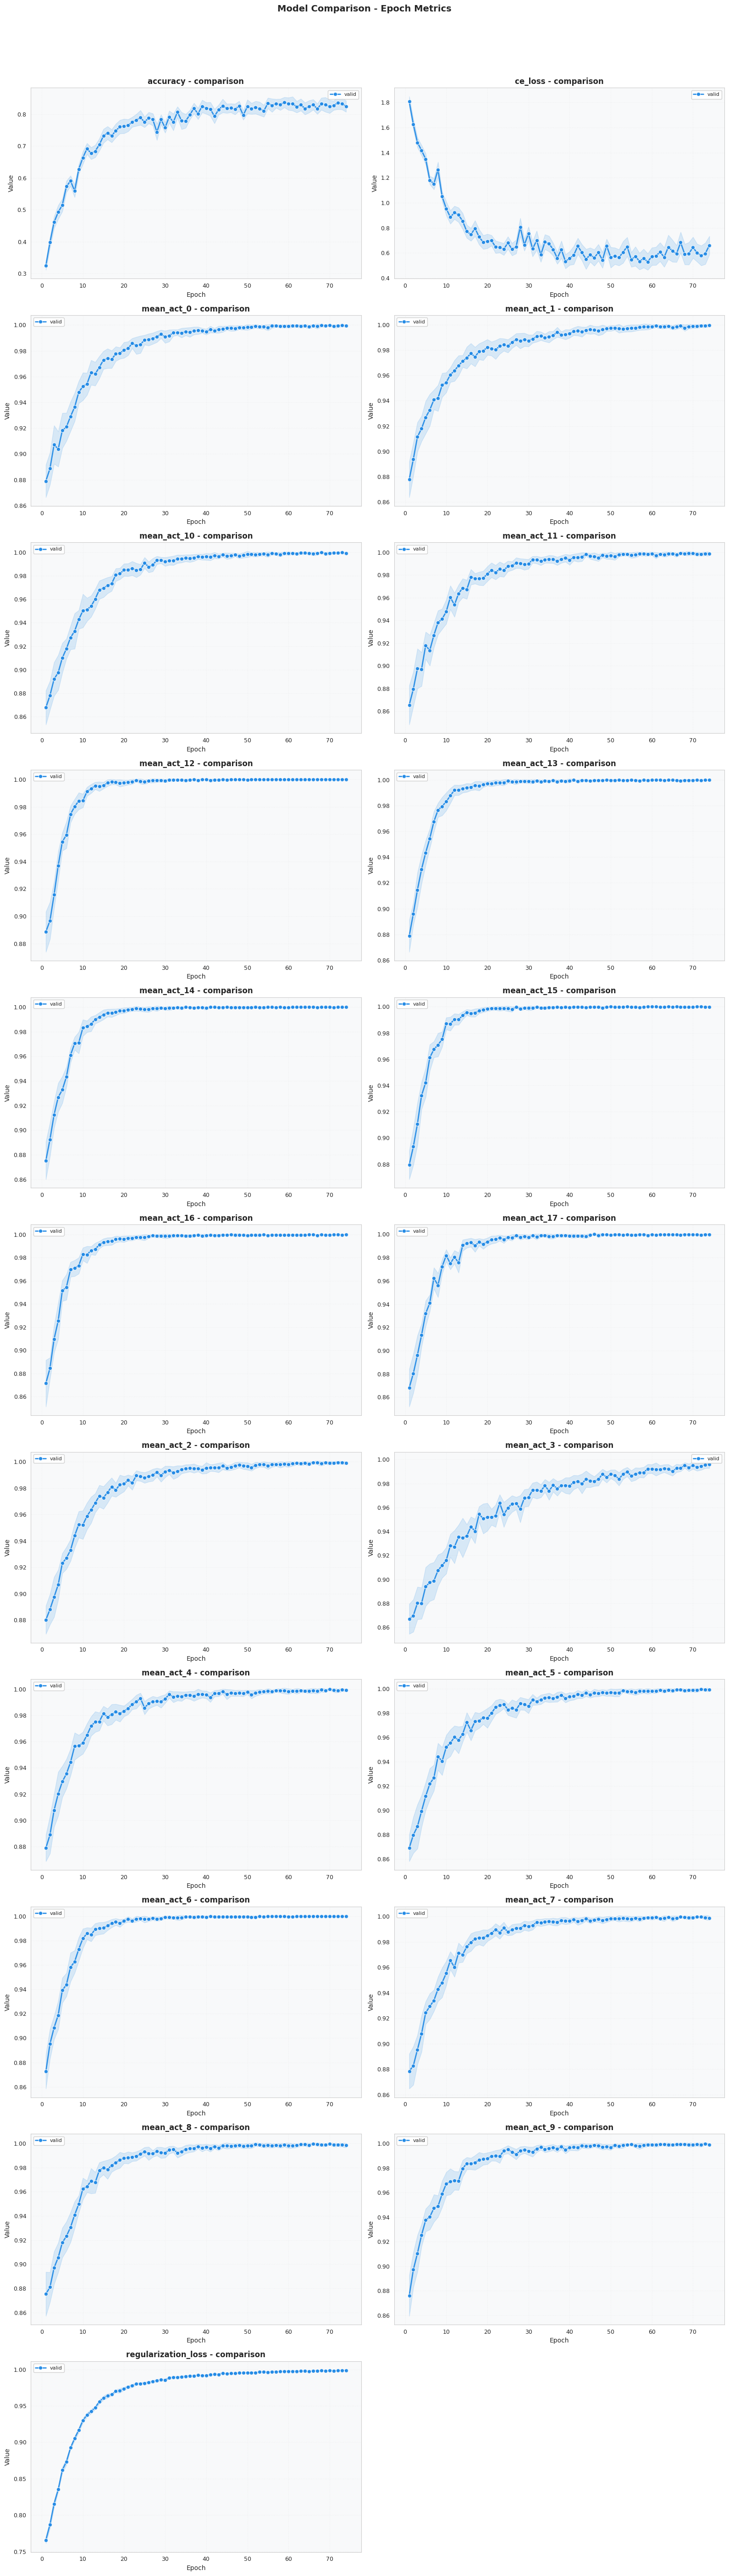

test accuracy: 0.8276482077205882 


In [10]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = ClassificationFeatureSelectionWrapperGumbel(
    backbone = ResNetMini_cifar(),
    lambda_coef = 0.0,
)
optimizer = torch.optim.Adam(model.parameters(), lr = 3e-4)
#optimizer = torch.optim.SGD(model.parameters(), lr = 3e-4)

metrics_0 = train(
    model,
    optimizer,
    train_loader,
    val_loader,
    device,
    num_epochs=100,
    patience=15
)

compare_epoch_metrics(
    metrics_list=[metrics_0[2]],
    metrics_per_epoch_list=[metrics_0[3]],
    names=['valid']
)

test_metrics = evaluate(
    model,
    test_loader,
    device
)

print(f'test accuracy: {np.mean(test_metrics["accuracy"])} ')

  0%|          | 0/100 [00:00<?, ?it/s]

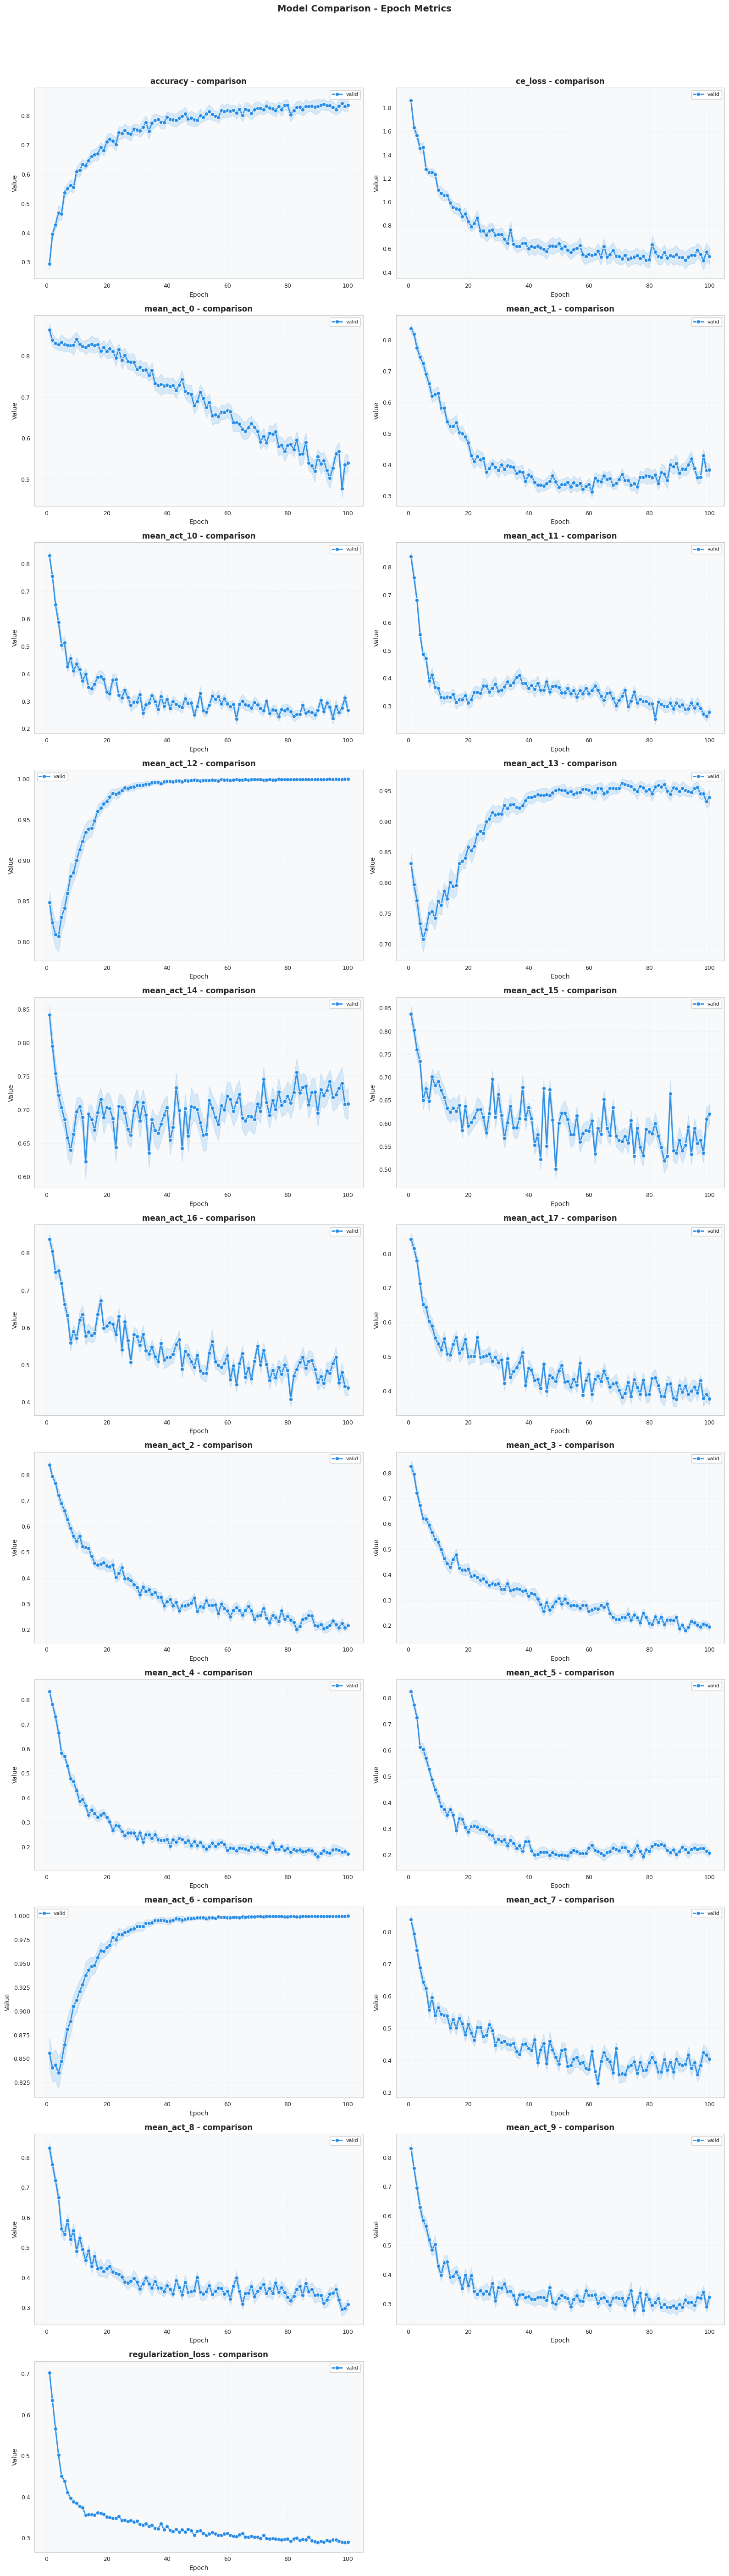

test accuracy: 0.8369083180147058 


In [11]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = ClassificationFeatureSelectionWrapperGumbel(
    backbone = ResNetMini_cifar(),
    lambda_coef = 0.5,
)
optimizer = torch.optim.Adam(model.parameters(), lr = 3e-4)
#optimizer = torch.optim.SGD(model.parameters(), lr = 3e-4)

metrics_05 = train(
    model,
    optimizer,
    train_loader,
    val_loader,
    device,
    num_epochs=100,
    patience=15
)

compare_epoch_metrics(
    metrics_list=[metrics_05[2]],
    metrics_per_epoch_list=[metrics_05[3]],
    names=['valid']
)

test_metrics = evaluate(
    model,
    test_loader,
    device
)

print(f'test accuracy: {np.mean(test_metrics["accuracy"])} ')

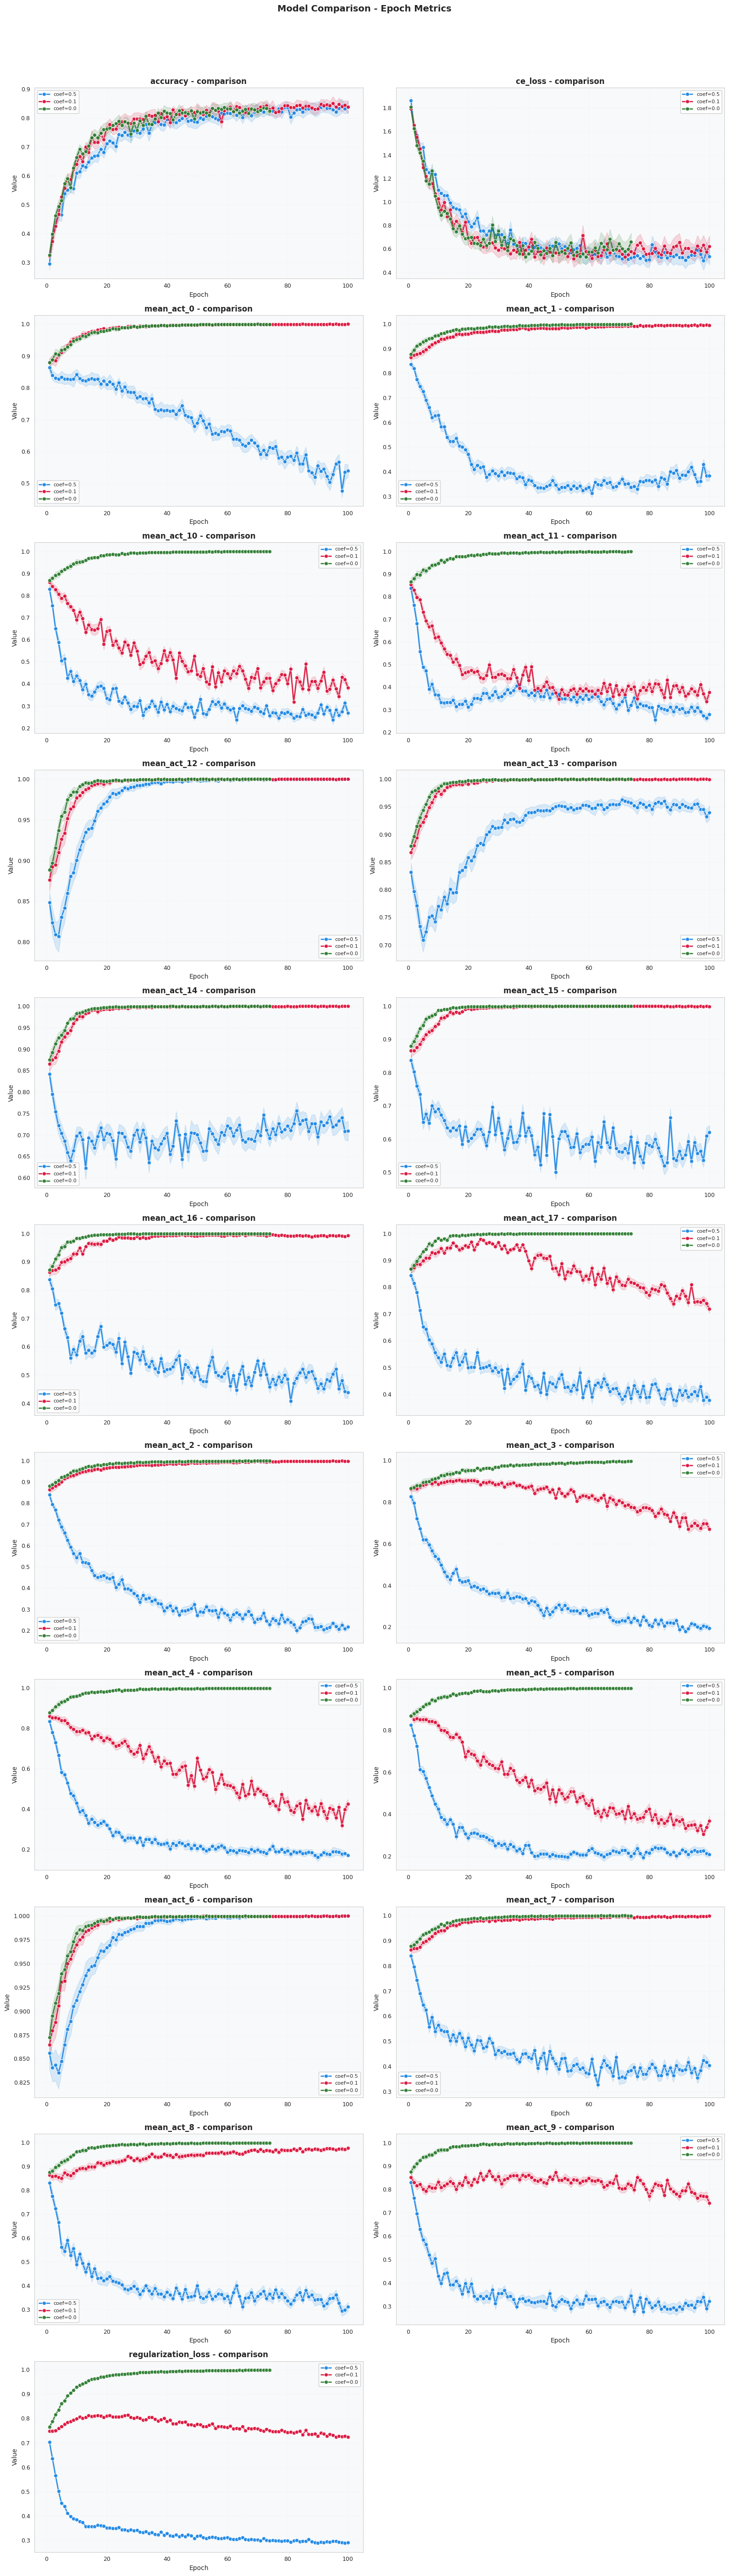

In [12]:
compare_epoch_metrics(
    metrics_list=[metrics_05[2], metrics_01[2], metrics_0[2]],
    metrics_per_epoch_list=[metrics_05[3], metrics_01[3], metrics_0[3]],
    names=['coef=0.5', 'coef=0.1', 'coef=0.0']
)